# Single-Stock Return Analysis - Meta Plafroms (2012-2026)

**Question:** What do the return, volatility, and drawdown characteristics of a single large-cap equity look like - and how far do they depart from the normal distribution assumed by introductory models? 

**Data:** Yahoo Finance daily prices via 'yfinance' ('auto_adjust=True', so splits and dividends are folded in - daily percent change approximates a total return).
Downloaded once and cahed to 'data/'; the analysis reads from disk.

**Author:** Alexandre • [Github](https://github.com/alexandret-11) • [LinkedIn](https://linkedin.com/in/alexandrethompson)

---
*Project 1 of a 7-projext quantitative research portfolio. Next: multi-asset comparison and correlation structure*

## Setup

Interim data source qhile WRDS/CRSP access is pending. The pull is isolated in a singkle cell so that the data layer can be swapped for CRSP later without touching any analysis code.

## Data

One network call, then cached. Two data-handling detials worth flagging: newer 'yfinance' versions return two-level columns (flattened at the boundary below), and the first row's return is 'NaN by construction - a series of *n* prices yields *n-1* returns.

In [10]:
# Block 0 - Data Pull(Yahoo Finance)
# Interim source while WRDS summer access is pending

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# auto_adjust=True -> closes adjusted for splits AND dividends, so pct_change
# approximates a total return
raw = yf.download(
    "META",
    start="2012-05-18",  # IPO date
    auto_adjust=True,
    progress=False,
)

# Newer yfinance returns MultiIndex columns (built for multi-ticker calls);
# flatten so raw["Close"] works across versions
if isinstance(raw.columns, pd.MultiIndex):
    raw.columns = raw.columns.get_level_values(0)

# .copy() serves df from raw -> avoids SettingWithCopyWarning on assignment
df = raw[["Close"]].rename(columns={"Close": "px_adj"}).copy()
df["ret"] = df["px_adj"].pct_change()
df.to_csv("../data/meta_prices_yf.csv")

# Four Diagnostic Tests
print(df.shape)
print(df.head(3))
print(df.tail(3))
print(df["ret"].isna().sum())

(3585, 2)
Price          px_adj       ret
Date                           
2012-05-18  37.897202       NaN
2012-05-21  33.733765 -0.109861
2012-05-22  30.730141 -0.089039
Price           px_adj       ret
Date                            
2026-08-19  546.030029  0.004341
2026-08-20  545.830017 -0.000366
2026-08-21  549.900024  0.007457
1


In [32]:
df["log"] = np.log(df["px_adj"]).diff()

print(df[["ret", "log"]].describe())

gap = (df["ret"] - df["log"]).abs()
print(df.loc[gap.nlargest(5).index, ["ret", "log"]])

print(
    f"Worst day: {df['ret'].idxmin().date()} "
    f"simple {df['ret'].min():.2%}, "
    f"log {df['log'].min():.2%}"
)

Price          ret          log
count  3584.000000  3584.000000
mean      0.001062     0.000746
std       0.025118     0.025121
min      -0.263901    -0.306391
25%      -0.010202    -0.010254
50%       0.000952     0.000952
75%       0.012689     0.012609
max       0.296115     0.259371
Price            ret       log
Date                          
2022-02-03 -0.263901 -0.306391
2013-07-25  0.296115  0.259371
2022-10-27 -0.245571 -0.281794
2023-02-02  0.232824  0.209307
2018-07-26 -0.189609 -0.210239
Worst day: 2022-02-03 simple -26.39%, log -30.64%


KeyError: Timestamp('2012-02-03 00:00:00')

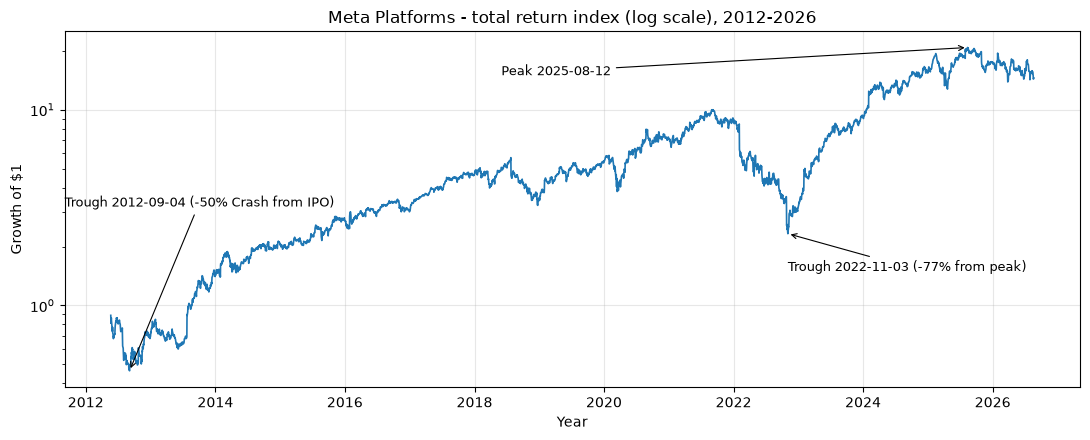

In [ ]:
r = df["ret"].dropna()
tri = (1 + r).cumprod()  # total return index, starts at ~1

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tri.index, tri.values, lw=1.2)
ax.set_yscale("log")
ax.set_title("Meta Platforms - total return index (log scale), 2012-2026")
ax.set_xlabel("Year")
ax.set_ylabel("Growth of $1")
ax.grid(alpha=0.3)
plt.tight_layout()

# --- annotations: peak, trough, worst single day ---
peak_dt = tri.loc["2012":"2026"].idxmax()
trough1_dt = tri.loc["2012":"2026"].idxmin()
trough2_dt = tri.loc["2022":"2026"].idxmin()
crash_dt = pd.Timestamp("2012-02-03")

ax.annotate(
    f"Peak {peak_dt.date()}",
    xy=(peak_dt, tri[peak_dt]),
    xytext=(pd.Timestamp("2018-06-01"), 15),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

ax.annotate(
    f"Trough {trough1_dt.date()} (-50% Crash from IPO)",
    xy=(trough1_dt, tri[trough1_dt]),
    xytext=(pd.Timestamp("2011-09-04"), 3.2),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

ax.annotate(
    f"Trough {trough2_dt.date()} (-77% from peak)",
    xy=(trough2_dt, tri[trough2_dt]),
    xytext=(pd.Timestamp("2022-11-03"), 1.5),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

crash_dt = df["ret"].idxmin()

ax.annotate(
    f"Worst day {crash_dt.date()}: −{abs(df['ret'].min()):.1%}",
    xy=(crash_dt, tri[crash_dt]),
    xytext=(pd.Timestamp("2023-08-01"), 8),
    arrowprops=dict(arrowstyle="->", lw=0.8),
    fontsize=9,
)

fig.savefig("../output/fig1_total_return_index.png", dpi=150, bbox_inches="tight")


### The Story Behind the Price

1. The initial trough of September 5, 2012 was a few months after the inital public offering where the stock dropped rougly 50% from its peak back on the opening day.
2. Almost 10 years after, the stock say a dramatic downfall of roughly 77% due to ...
3. Following the worst day